### **1. Importing the required packages**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### **2. Reading and Exploring the Data**

In [ ]:
customers = pd.read_csv('Mall_Customers.csv')

In [ ]:
customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
customers.shape

(200, 5)

In [ ]:
customers.drop(columns = ['CustomerID'], inplace = True)

In [ ]:
customers.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [ ]:
customers.isnull().sum(axis = 0)

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
customers.dtypes

,0
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [ ]:
customers.duplicated().sum()

np.int64(0)

In [ ]:
customers.drop_duplicates(inplace = True)

##### **Encoding the Gender column**

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [ ]:
le = LabelEncoder()
customers['Gender'] = le.fit_transform(customers['Gender'])

### **Machine Learning Process**

In [ ]:
customers.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
X = customers.iloc[:, 2:4].values  #.values will convert a dataframe into numpy array

In [ ]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

#### **Scaling of the data using Standardization**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### **WCSS Process for finding the optimal k-value**

In [ ]:
wcss = []

for k in range(1,11):
  kmeans = KMeans(n_clusters = k, init = "k-means++", random_state = 42)
  kmeans.fit(X_scaled) #clustering process starts here

  print(kmeans.inertia_) #.inertia_ stores the wcss values for each k
  wcss.append(kmeans.inertia_)

399.99999999999994
273.66888662642003
157.70400815035939
109.22822707921345
65.56840815571681
60.132874871934206
49.668244837367965
37.31912287833882
32.495081199100916
30.05932269404222


#### **Plot the graph between k-value and wcss**

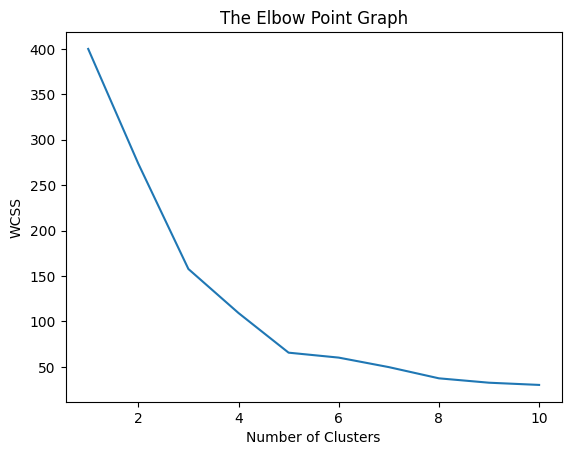

In [ ]:
plt.plot(range(1,11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

### **Silhouette score for optimal k**

In [ ]:
num_clusters = [i for i in range(2, 11)]

def kmeans_sil(num_clusters, X):

    sil_score = []
    for k in num_clusters:
        kms = KMeans(n_clusters=k, init = 'k-means++', random_state = 42)
        kms.fit(X)

        sil_score.append(silhouette_score(X, kms.labels_))

    return sil_score

In [ ]:
num_clusters

[2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
sil_score = kmeans_sil(num_clusters, X_scaled)
sil_score

[np.float64(0.3973270007887498),
 np.float64(0.46658474419000145),
 np.float64(0.49434988482196784),
 np.float64(0.5546571631111091),
 np.float64(0.5138257534676561),
 np.float64(0.50200146805547),
 np.float64(0.4550112502601921),
 np.float64(0.4566624374485964),
 np.float64(0.44475993501732874)]

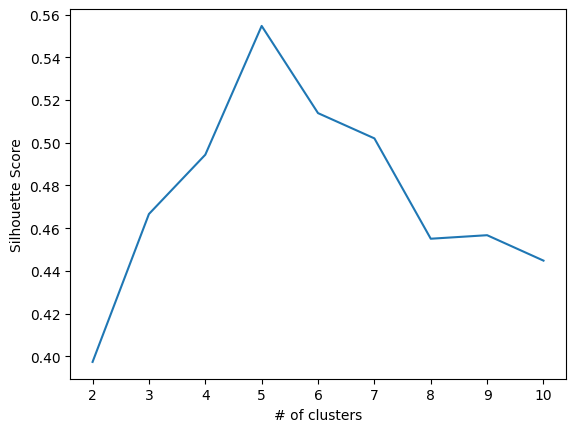

In [ ]:
# Create a line plot of silhouette scores
plot = sns.lineplot(x=num_clusters, y=sil_score)
plot.set_xlabel("# of clusters");
plot.set_ylabel("Silhouette Score");

#### **Apply KMeans Clustering on the data**

In [ ]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++')
kmeans.fit(X_scaled) #here we start the clustering process where data will be divided into 5 clusters

KMeans(n_clusters=5)

In [ ]:
y = kmeans.predict(X_scaled) #it will tell us in which cluster which datapoint has been put

In [ ]:
y

array([4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 1,
       4, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 2, 1, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 1, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

In [ ]:
output = pd.DataFrame(y, columns = ['Cluster Number'])

In [ ]:
final_df = pd.concat([customers, output], axis = 1)

In [ ]:
final_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster Number
0,1,19,15,39,4
1,1,21,15,81,3
2,0,20,16,6,4
3,0,23,16,77,3
4,0,31,17,40,4


### Visualize the clusters

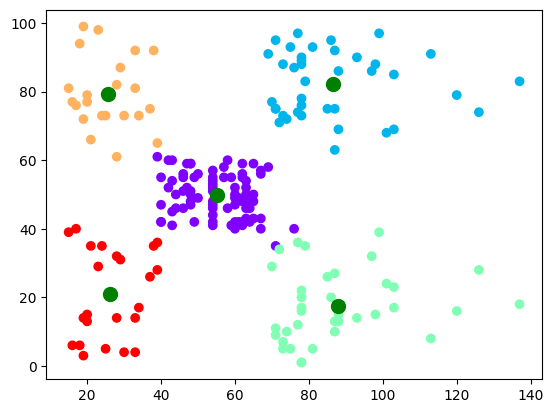

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'green')
plt.show()

    k     inertia  silhouette  davies_bouldin
0   2  273.668887    0.397327        0.959667
1   3  157.704008    0.466585        0.716482
2   4  109.228227    0.494350        0.697460
3   5   65.568408    0.554657        0.572236
4   6   60.132875    0.513826        0.623895
5   7   49.668245    0.502001        0.692508
6   8   37.319123    0.455011        0.766771
7   9   32.495081    0.456662        0.758805
8  10   30.059323    0.444760        0.766795


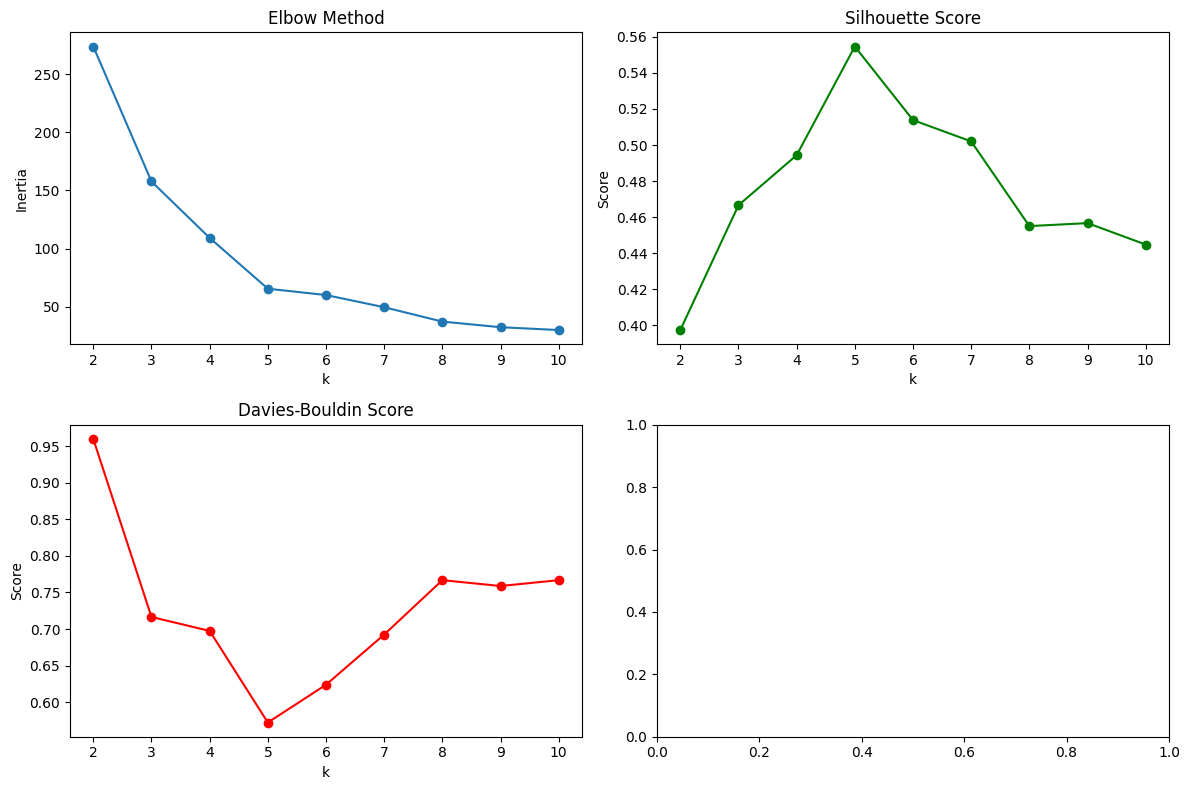

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

k_values = range(2, 11)
results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels)
    })

results_df = pd.DataFrame(results)
print(results_df)

# Plot metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(results_df["k"], results_df["inertia"], marker="o")
axes[0, 0].set_title("Elbow Method")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("Inertia")

axes[0, 1].plot(results_df["k"], results_df["silhouette"], marker="o", color="green")
axes[0, 1].set_title("Silhouette Score")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("Score")

axes[1, 0].plot(results_df["k"], results_df["davies_bouldin"], marker="o", color="red")
axes[1, 0].set_title("Davies-Bouldin Score")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("Score")

plt.tight_layout()
plt.show()